# Stable Diffusion

**Diffusion model**은 데이터에 noise를 점차 섞는 과정을 거꾸로 학습하여 새로운 데이터를 만드는 생성 모델이다. <br> 학습할 때는 깨끗한 이미지에 섞인 noise를 맞히고, 추론할 때는 무작위 noise에서 예측한 noise를 여러 번 제거해 이미지를 만든다.

**Stable Diffusion**은 이 과정을 픽셀 공간이 아니라 **latent space(잠재 공간)** 에서 수행한다. VAE(Variational Autoencoder, 변분 오토인코더)가 이미지를 더 작은 latent 표현으로 압축하므로 이미지의 핵심 특징을 유지하면서 메모리와 연산량을 줄일 수 있다.

## 학습과 추론의 경계

- **학습**: 실제 이미지의 latent에 임의의 시점만큼 noise를 섞고, noise 예측 신경망인 U-Net denoiser가 그 noise를 맞히도록 가중치를 갱신한다.
- **추론**: 학습된 가중치는 고정한다. 초기 random latent에서 U-Net과 단계별 갱신 규칙인 scheduler를 반복 실행하며 noise를 제거하고, prompt는 각 단계에서 생성 방향을 안내한다.


## 정방향 확산 수식

정방향 확산은 깨끗한 데이터에 noise를 조금씩 누적해 특정 시점의 noisy data를 만드는 과정이다. 모델이 다양한 noise 수준을 경험해야 어느 단계의 noisy latent에서도 제거할 noise를 학습할 수 있다.

아래 식은 여러 단계를 하나씩 계산하지 않고 $x_0$에서 원하는 시점 $t$의 $x_t$를 바로 만드는 식이다. 다음 기호를 먼저 구분한다.

- $x_0$: noise가 섞이기 전의 깨끗한 이미지 또는 latent이다.
- $\epsilon \sim \mathcal{N}(0, I)$: 정규분포에서 뽑은 random noise이다.
- $\beta_t$: $t$번째 step에서 새로 추가할 noise의 분산 비중을 정하는 값이다.
- $\alpha_t = 1-\beta_t$: $t$번째 step에서 이전 신호 성분의 분산을 유지하는 비율이다.
- $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$: 1번째부터 $t$번째까지 누적된 원본 신호 성분의 분산 비중이다.

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon
$$

첫 번째 항은 원본에 $\sqrt{\bar{\alpha}_t}$를 곱한 신호이고, 두 번째 항은 noise에 $\sqrt{1-\bar{\alpha}_t}$를 곱한 값이다. $\bar{\alpha}_t$가 작아질수록 원본 성분의 비중은 줄고 noise 성분의 비중은 커진다.

다음 Tensor 예제에서는 `clean`이 $x_0$, `epsilon`이 $\epsilon$, `alpha_bar_t`가 $\bar{\alpha}_t$, `x_t`가 noisy data에 대응한다.

## 필수 패키지 설치


In [1]:
%pip install -U diffusers transformers "peft>=0.19.1" accelerate safetensors pillow matplotlib python-dotenv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 48.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 7.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 65.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 57.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 32.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 7.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 57.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 33.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 40.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.0/802.0 kB 18.2 MB/s  0:00:00
  Attempting uninstall: pillow90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/26 [regex]
    Found existing installation: pillow 11.0.0━━━━━━━━━━━━━━━━  4/26 [reg

## Hugging Face 인증과 실행 장치 선택

In [2]:
from pathlib import Path

import torch
from dotenv import find_dotenv, load_dotenv
from IPython.display import display

# find_dotenv()는 현재 폴더에서 시작해 상위 폴더 방향으로 .env 경로를 찾는다.
# load_dotenv()는 HF_TOKEN을 포함한 값을 환경변수로 등록하되 기존 환경변수는 덮어쓰지 않는다.
load_dotenv(find_dotenv())

# CUDA, Apple Silicon MPS, CPU 순서로 사용할 수 있는 장치를 선택한다.
if torch.cuda.is_available():
    device = "cuda"
    weight_dtype = torch.float16  # CUDA에서는 절반 정밀도로 VRAM 사용량을 줄인다.
elif torch.backends.mps.is_available():
    device = "mps"
    weight_dtype = torch.float32  # MPS에서는 연산 호환성을 위해 float32를 사용한다.
else:
    device = "cpu"
    weight_dtype = torch.float32  # CPU의 float16 연산은 느리거나 미지원일 수 있다.

print("device:", device)
print("weight dtype:", weight_dtype)


device: cuda
weight dtype: torch.float16


## 정답 noise와 예측 noise의 차이

정방향 식에서 사용한 정확한 `epsilon`을 알고 있다면 식을 거꾸로 계산해 `clean`을 복원할 수 있다. 이 계산은 수식이 맞는지 확인하는 예제이며, 실제 이미지 생성 상황과는 다르다.

- 생성 모델에서의 epsilon : Noise 벡터 (Noise의 위치)

실제 추론에는 복원해야 할 정답 `clean`이 없으므로 현재 latent를 만든 정답 noise를 직접 계산할 수 없다. 그래서 학습된 U-Net denoiser가 현재 latent에서 제거할 noise인 `predicted_epsilon`을 예측하고, scheduler가 이 예측을 이용해 다음 단계의 조금 더 깨끗한 latent를 계산한다.

다음 예제는 예측 noise에 작은 오차를 일부러 더한다. `exact_recovered`와 `estimated_recovered`의 최대 오차를 비교하면 noise 예측의 정확도가 복원 결과에 직접 영향을 준다는 사실을 확인할 수 있다.

In [3]:
torch.manual_seed(7)

# clean은 수식의 x_0이며 두 숫자는 실제 이미지 대신 사용하는 작은 특징 벡터이다.
# randn_like()는 clean과 같은 shape인 (2,)의 정규분포 noise epsilon을 만든다.
clean = torch.tensor([1.0, -1.0])
epsilon = torch.randn_like(clean)
alpha_bar_t = torch.tensor(0.8)  # 원본 성분의 분산 비중을 0.8로 두며 실제 x_0 계수는 sqrt(0.8)이다.

# 정방향 수식으로 원본 신호와 noise를 가중합해 같은 shape (2,)의 x_t를 만든다.
x_t = torch.sqrt(alpha_bar_t) * clean + torch.sqrt(1 - alpha_bar_t) * epsilon

# 정답 epsilon을 그대로 빼는 계산은 모델 추론이 아니라 수식 확인용 대수적 복원이다.
exact_recovered = (x_t - torch.sqrt(1 - alpha_bar_t) * epsilon) / torch.sqrt(alpha_bar_t)

# 실제 denoiser의 상황을 흉내 내기 위해 정답 epsilon에 알려진 예측 오차를 더한다.
prediction_error = torch.tensor([0.2, -0.1])
predicted_epsilon = epsilon + prediction_error
estimated_recovered = (x_t - torch.sqrt(1 - alpha_bar_t) * predicted_epsilon) / torch.sqrt(alpha_bar_t)

print("clean:", clean.tolist())
print("x_t:", x_t.tolist())

# 정확한 epsilon을 이용해서 복원
print("exact recovered:", exact_recovered.tolist())

# 예측을 통한 복원
print("estimated recovered:", estimated_recovered.tolist())
print("exact max error:", torch.max(torch.abs(clean - exact_recovered)).item())
print("estimated max error:", torch.max(torch.abs(clean - estimated_recovered)).item())


clean: [1.0, -1.0]
x_t: [0.8287783861160278, -0.5428541302680969]
exact recovered: [1.0, -1.0]
estimated recovered: [0.8999999761581421, -0.949999988079071]
exact max error: 0.0
estimated max error: 0.10000002384185791


## Latent Diffusion pipeline의 구성 요소

Latent Diffusion은 큰 픽셀 배열에서 직접 noise를 제거하지 않고, VAE가 압축한 작은 latent에서 연산한다. Stable Diffusion pipeline은 다음 구성 요소가 각자의 입력을 변환하고 결과를 다음 단계로 넘기는 구조이다.

Shape에서 `B`는 한 번에 처리하는 이미지 수, `3`은 RGB 채널, `H`와 `W`는 이미지 높이와 너비이다. Latent의 `4`는 압축된 특징 채널 수이며, `H/8`과 `W/8`은 공간 크기가 각각 8분의 1로 줄었다는 뜻이다.

- **VAE(Variational Autoencoder) encoder**: 학습 이미지의 픽셀 `(B, 3, H, W)`를 latent `(B, 4, H/8, W/8)`로 압축한다. 순수 text-to-image 추론은 random latent에서 시작하므로 이 실습의 생성 호출에서는 encoder를 사용하지 않는다.
- **Tokenizer와 CLIP text encoder**: CLIP(Contrastive Language-Image Pre-training)의 텍스트 인코더가 prompt를 token ID와 문맥을 담은 text embedding으로 변환한다. 이 embedding은 U-Net이 어떤 내용을 생성해야 하는지 판단하는 조건이 된다.
- **Cross-attention**: U-Net의 latent 특징이 text embedding의 여러 token 중 현재 위치에서 참고할 내용을 선택하는 연산이다. 이 연결을 통해 prompt 조건이 이미지 생성 과정에 반영된다.
- **U-Net denoiser**: 현재 noisy latent, 현재 timestep, text embedding을 입력받아 제거해야 할 noise를 예측한다. 즉, U-Net은 완성 이미지를 한 번에 출력하지 않는다.
- **Scheduler**: U-Net이 예측한 noise와 timestep을 이용해 $x_t$를 더 깨끗한 $x_{t-1}$로 갱신한다. Scheduler는 반복 순서와 계산 공식을 관리하는 규칙이며 학습된 신경망과 구분된다.
- **VAE decoder**: 반복이 끝난 latent를 사람이 볼 수 있는 RGB 픽셀 이미지로 복원한다.

### 생성 결과를 조절하는 값

- **Prompt**: 생성할 대상·배경·스타일을 자연어로 표현한 조건이다.
- **Seed**: 최초 random latent를 만드는 난수 시작값이다. 같은 모델과 설정에서 seed를 고정하면 비교 실험의 출발점을 맞출 수 있다.
- **`num_inference_steps`**: U-Net의 noise 예측과 scheduler의 latent 갱신을 반복하는 횟수이다. 값을 늘리면 계산 시간도 증가하지만 품질이 항상 비례해 좋아지지는 않는다.
- **`guidance_scale`**: prompt가 있는 예측과 없는 예측의 차이를 얼마나 강조할지 정하는 값이다. 높이면 prompt 반영은 강해지지만 지나치면 왜곡이나 부자연스러운 질감이 생길 수 있다.

![Stable Diffusion의 latent diffusion pipeline](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@3ab0a09bc9f78a59f3d9f5bf91b3f4fb7ea4005b/09_multimodal/05_image_generation/03_latent_diffusion_pipeline.svg)

그림은 `prompt → text embedding → U-Net 조건`, `random latent → 반복 denoising → final latent`, `final latent → VAE decoder → image`의 세 흐름으로 읽는다. 가운데 loop에서 U-Net은 noise를 예측하고 scheduler는 latent를 한 단계 갱신하며, 이 두 연산이 `num_inference_steps`만큼 반복된다. 반복이 끝난 latent만 VAE decoder를 통과해 최종 이미지가 된다.

### Stable Diffusion v1 구조도

![Hugging Face가 설명하는 Stable Diffusion v1 추론 구조](https://raw.githubusercontent.com/patrickvonplaten/scientific_images/master/stable_diffusion.png)

왼쪽의 `64×64` random latent는 기본 `512×512` 이미지를 가로와 세로 각각 8분의 1로 압축한 공간 표현이다. 이 latent가 U-Net의 noise 예측과 scheduler의 갱신을 반복하면서 점차 정제된다.

오른쪽에서는 prompt가 CLIP text encoder를 거쳐 `77×768` text embedding이 된다. `77`은 `[시작 token]`과 `[종료 token]`을 포함한 최대 token 위치 수이고, `768`은 각 token을 표현하는 특징 차원 수이다. U-Net은 cross-attention으로 이 문장 조건을 참고해 각 denoising step의 noise를 예측하고, 마지막 latent는 VAE decoder를 거쳐 `512×512` 이미지로 복원된다.


출처": [Hugging Face Stable Diffusion 해설](https://huggingface.co/blog/stable_diffusion#how-does-stable-diffusion-work)

## Stable Diffusion pipeline 불러오기

`StableDiffusionPipeline.from_pretrained()`는 모델 저장소의 설정 파일을 읽고 VAE, CLIP text encoder, U-Net, scheduler의 사전학습 가중치를 하나의 pipeline 객체로 조립한다. 각 구성 요소를 직접 연결하는 대신 검증된 추론 순서를 한 번의 호출로 사용할 수 있게 한다.

`MODEL_ID`는 내려받을 저장소를 지정하고, `dtype`은 가중치를 메모리에 올릴 정밀도를 정한다. `use_safetensors=True`는 pickle 실행 코드가 없는 safetensors 가중치를 우선 사용한다. 앞에서 등록한 `HF_TOKEN`은 Hugging Face Hub 요청에 자동으로 사용되며 코드에 직접 전달하거나 출력하지 않는다.

첫 실행에는 인터넷 연결, 모델 cache를 저장할 디스크 공간과 충분한 메모리가 필요하다. 다운로드와 조립이 끝난 뒤 `pipe.to(device)`가 전체 구성 요소를 선택한 연산 장치로 이동하며, 다음 생성 셀은 이 `pipe`를 사용한다. 모델 ID와 호출 방식은 [Hugging Face Diffusers 공식 문서](https://huggingface.co/docs/diffusers/api/pipelines/stable_diffusion/text2img)를 따른다.

In [4]:
from diffusers import StableDiffusionPipeline

# Hugging Face Hub에서 불러올 Stable Diffusion v1.5 저장소의 고유 ID이다.
MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

# dtype은 가중치의 메모리 정밀도이며 CUDA에서는 float16으로 VRAM 사용량을 줄인다.
# use_safetensors=True는 임의 코드 실행 위험이 없는 safetensors 형식을 선택한다.
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    dtype=weight_dtype,
    use_safetensors=True,
)

# .to(device)는 pipeline의 신경망 가중치를 앞에서 선택한 GPU·MPS·CPU 메모리로 이동한다.
pipe = pipe.to(device)
pipe.set_progress_bar_config(disable=False)

print("pipeline:", pipe.__class__.__name__)
print("model:", MODEL_ID)
print("device:", pipe.device)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

pipeline: StableDiffusionPipeline
model: stable-diffusion-v1-5/stable-diffusion-v1-5
device: cuda:0


## 단일 prompt로 이미지 생성하고 저장

Prompt는 생성할 대상·장면·스타일을 text encoder에 전달하는 자연어 조건이다. 현재 문장은 `산과 일출`이라는 내용과 `수채화`라는 표현 방식을 함께 지정한다.

생성은 prompt만으로 결정되지 않고 최초 random latent에도 영향을 받는다. `torch.Generator`에 seed를 지정하면 같은 출발 latent를 다시 만들 수 있으므로 설정을 공정하게 비교할 수 있다.

`num_inference_steps`는 noise 제거 반복 횟수이고 `guidance_scale`은 prompt 조건을 강조하는 정도이다. Pipeline이 반환한 `result.images`는 PIL 이미지 목록이며, 다음 코드는 첫 번째 이미지를 노트북에 표시하고 상대 경로 `outputs/`에 저장한다.

  0%|          | 0/30 [00:00<?, ?it/s]

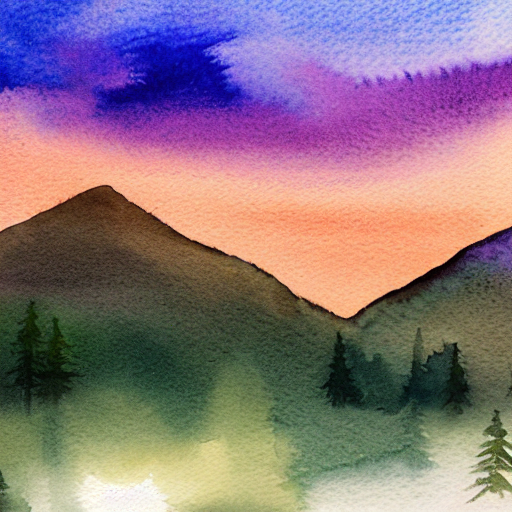

image size: (512, 512)
saved: outputs/stable_diffusion_single.png


In [5]:
PROMPT = "A serene landscape of mountains during sunrise, watercolor style"
SEED = 42
NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE = 7.5

# CPU Generator는 같은 seed에서 같은 난수열을 시작해 최초 random latent를 재현한다.
generator = torch.Generator(device="cpu").manual_seed(SEED)

result = pipe(
    prompt=PROMPT,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    generator=generator,
)
image = result.images[0]

output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "stable_diffusion_single.png"
image.save(output_path)

display(image)
print("image size:", image.size)
print("saved:", output_path)


### `guidance_scale` 비교

| `guidance_scale=2.5` | `guidance_scale=7.5` | `guidance_scale=10.5` |
|---|---|---|
| ![guidance scale 2.5 예시](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/text2img-guidance-scale-2.5.png) | ![guidance scale 7.5 예시](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/text2img-guidance-scale-7.5.png) | ![guidance scale 10.5 예시](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/text2img-guidance-scale-10.5.png) |

`guidance_scale`은 **Classifier-Free Guidance(CFG)**의 강도이다. Pipeline은 prompt가 있는 noise 예측과 prompt가 없는 noise 예측을 함께 계산하고, 두 예측의 차이를 이 값만큼 강조해 prompt 방향으로 latent를 갱신한다.

낮은 값은 prompt 조건이 느슨하게 반영되고, 중간 값은 prompt 반영과 자연스러움이 비교적 균형을 이룬다. 너무 높은 값은 prompt를 강하게 따르는 대신 왜곡, 과도한 대비, 인공적인 질감이 나타날 수 있으므로 큰 값이 항상 좋은 결과를 보장하지 않는다.

공식 그림은 `2.5`, `7.5`, `10.5`의 일반적인 변화 경향을 보여 주며, 아래 코드는 같은 원리를 `3.0`과 `9.0`으로 직접 비교한다. 출처는 [Hugging Face Diffusers 공식 문서](https://huggingface.co/docs/diffusers/en/using-diffusers/conditional_image_generation#guidance-scale)이다.

## 같은 prompt와 seed에서 guidance_scale 비교

두 결과의 차이를 `guidance_scale`의 영향으로 해석하려면 prompt, seed, steps, 모델을 모두 고정해야 한다. 여러 조건이 함께 달라지면 어떤 값이 이미지 차이를 만든 것인지 판단할 수 없기 때문이다.

한 Generator를 생성 호출에 사용하면 내부 random state가 다음 위치로 진행된다. 따라서 반복마다 같은 seed의 새 Generator를 만들어 두 실행이 동일한 최초 latent에서 시작하도록 한다.

다음 코드는 `guidance_scale`만 `3.0`과 `9.0`으로 바꾸고 두 이미지를 나란히 표시한다. 객체·배경·스타일이 prompt와 얼마나 일치하는지와 이미지의 색·질감·형태가 자연스러운지를 함께 비교한다.

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

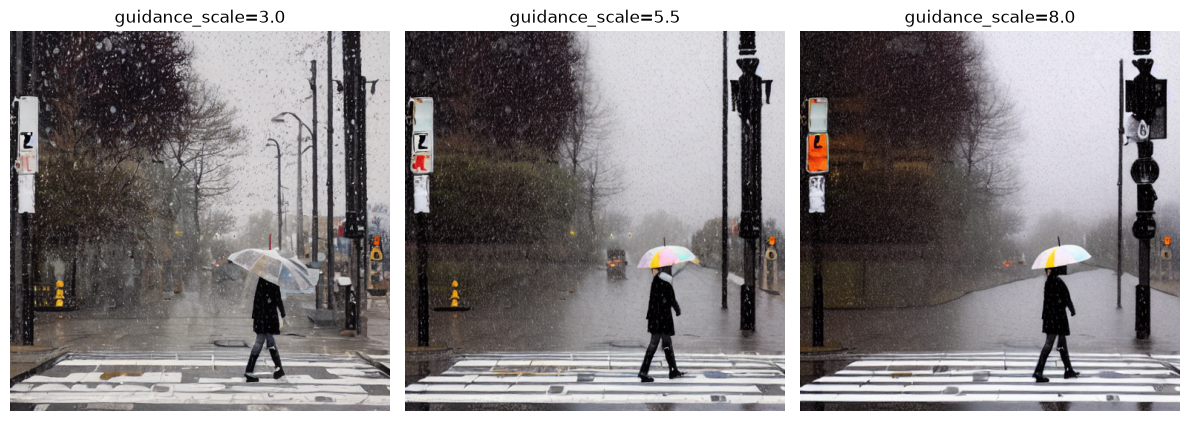

saved: outputs/stable_diffusion_guidance_comparison.png


In [11]:
import matplotlib.pyplot as plt

guidance_values = [3.0, 5.5, 8.0]
comparison_images = []

for guidance in guidance_values:
    comparison_generator = torch.Generator(device="cpu").manual_seed(SEED)

    comparison_result = pipe(
        prompt='A person standing at a crosswalk holding an umbrella on a rainy day',
        num_inference_steps=NUM_INFERENCE_STEPS,
        guidance_scale=guidance,
        generator=comparison_generator,
    )
    comparison_images.append(comparison_result.images[0])

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for axis, generated_image, guidance in zip(axes, comparison_images, guidance_values):
    axis.imshow(generated_image)
    axis.set_title(f"guidance_scale={guidance}")
    axis.axis("off")

comparison_path = output_dir / "stable_diffusion_guidance_comparison.png"
fig.tight_layout()
fig.savefig(comparison_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", comparison_path)